Taller 3 Deep Learning

Se solicita desarrollar los siguiente punto para poder responder las preguntas del final

1. Preparación del dataset  
2. Fundamentos de la entrada (tensores de imágenes)  
3. Definición de la arquitectura de la CNN  
4. Hiperparámetros principales  
5. Función de pérdida y optimizador  
6. Proceso de entrenamiento  
7. Uso de *callbacks* (EarlyStopping, ModelCheckpoint)  
8. Diagnóstico del entrenamiento (curvas de aprendizaje)  
9. Evaluación del modelo (métricas en test, matriz de confusión, reporte)  

Usaremos el dataset **MNIST** (dígitos escritos a mano), que es rápido y muy útil para cnn

Nombres:

* Cristian Gonzalez

* Rodrigo Hernandez

* Nicolas Herrera

* Willioxer Paz

*

## 0. Importar librerías

Primero importamos todas las librerías necesarias:

- `numpy` para manejo de arreglos numéricos.
- `matplotlib` para graficar.
- `tensorflow.keras` para construir y entrenar la CNN.
- `sklearn.metrics` para métricas de evaluación como matriz de confusión y reporte de clasificación.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf # Added this import
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("Versión de TensorFlow:", keras.__version__)

Versión de TensorFlow: 3.13.2


## 1. Preparación del dataset

Usaremos el dataset **MNIST**, que viene incluido en Keras:

- 60.000 imágenes de entrenamiento.
- 10.000 imágenes de prueba.
- Cada imagen es de tamaño 28x28 píxeles, en **escala de grises** (un solo canal).

Pasos:

1. Cargar el dataset.
2. Normalizar los valores de los píxeles (de 0–255 a 0–1).
3. Añadir el **canal** para que el tensor sea `(alto, ancho, canales)`.
4. Separar un conjunto de **validación** a partir del conjunto de entrenamiento.


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Shape original de x_train:", x_train.shape)
print("Shape original de x_test :", x_test.shape)

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, -1)  # (60000, 28, 28, 1)
x_test = np.expand_dims(x_test, -1)    # (10000, 28, 28, 1)

print("Nuevo shape de x_train:", x_train.shape)
print("Nuevo shape de x_test :", x_test.shape)



Shape original de x_train: (60000, 28, 28)
Shape original de x_test : (10000, 28, 28)
Nuevo shape de x_train: (60000, 28, 28, 1)
Nuevo shape de x_test : (10000, 28, 28, 1)


Crear conjunto de validación (por ejemplo, 10% de x_train)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42
)

print("Shape x_train:", x_train.shape)
print("Shape x_val  :", x_val.shape)
print("Shape x_test :", x_test.shape)

Shape x_train: (54000, 28, 28, 1)
Shape x_val  : (6000, 28, 28, 1)
Shape x_test : (10000, 28, 28, 1)


### Visualizar algunos ejemplos del dataset

Es muy importante **mirar los datos** antes de entrenar cualquier modelo.


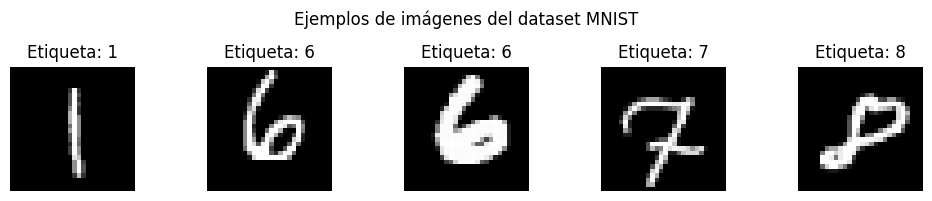

In [ ]:
# Mostrar algunas imágenes de ejemplo
num_imagenes = 5
plt.figure(figsize=(10, 2))

for i in range(num_imagenes):
    plt.subplot(1, num_imagenes, i+1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(f'Etiqueta: {y_train[i]}')
    plt.axis('off')

plt.suptitle('Ejemplos de imágenes del dataset MNIST')
plt.tight_layout()
plt.show()

## 2. Imágenes como tensores

Recordatorio rápido:

- Cada imagen se representa como un **tensor** de forma `(alto, ancho, canales)`.
- En este caso, las imágenes son de tamaño `28 x 28` y tienen `1` canal (escala de grises).
- Es decir, cada imagen tiene forma `(28, 28, 1)`.

El modelo CNN espera exactamente esta forma como `input_shape`.


## 3. Definición de la arquitectura de la CNN

Vamos a construir una CNN **simple pero completa**:

1. `Conv2D(32, kernel_size=3, activation='relu', padding='same')`
2. `MaxPooling2D(pool_size=2)`
3. `Conv2D(64, kernel_size=3, activation='relu', padding='same')`
4. `MaxPooling2D(pool_size=2)`
5. `Flatten()` para pasar de mapas de características a un vector.
6. `Dense(64, activation='relu')`
7. `Dense(10, activation='softmax')` como capa de salida (10 dígitos posibles).

Esta arquitectura sigue el patrón:

> Convolución → Pooling → Convolución → Pooling → Flatten → Dense → Salida


In [ ]:
# 3. Definir la arquitectura de la CNN
input_shape = (28, 28, 1)
num_clases = 10

modelo = keras.Sequential([
    layers.Input(shape=input_shape),

    # Bloque convolucional 1
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2),

    # Bloque convolucional 2
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2),

    # De mapas de características a vector
    layers.Flatten(),

    # Capa densa intermedia
    layers.Dense(64, activation='relu'),

    # Capa de salida
    layers.Dense(num_clases, activation='softmax')
])

modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Hiperparámetros principales

Al entrenar una CNN debemos decidir varios hiperparámetros:

- **Learning rate** (tasa de aprendizaje)  
- **Batch size** (tamaño de lote)  
- **Número de épocas (epochs)**  
- Optimizador (Adam, SGD, etc.)  

En este ejemplo usaremos:

- `learning_rate = 0.001`
- `batch_size = 128`
- `epochs = 10` (se puede cortar antes con EarlyStopping)
- Optimizador: **Adam** (buena opción por defecto)  


### Parámetros de entrenamiento en una CNN

| Parámetro | Definición | Valores posibles | Cómo influye en el aprendizaje |
|----------|------------|------------------|--------------------------------|
| **Learning Rate (lr)** | Controla qué tan grande es el paso que da el modelo al ajustar los pesos durante el entrenamiento. | Valores típicos: `1`, `0.1`, `0.01`, `0.001`, `0.0001`, `1e-5`, `1e-6`. Puede tomar *cualquier valor positivo*, pero normalmente se usa entre `1e-1` y `1e-6`. | Si es **muy alto**, el modelo se vuelve inestable y no converge. Si es **muy bajo**, aprende muy lento y puede quedarse atrapado en mínimos locales. Un buen lr permite una convergencia rápida y estable. |
| **Batch Size** | Cantidad de muestras que se usan para calcular un gradiente antes de actualizar los pesos. | Común: `16`, `32`, `64`, `128`, `256`, `512`. Debe ser un entero positivo y limitado por la memoria de la GPU/CPU. | Batches **pequeños** → entrenamiento más ruidoso pero mejor generalización. Batches **grandes** → entrenamiento más estable pero puede sobreajustar, y requieren más memoria. |
| **Epochs** | Número de veces que el modelo ve *todo* el dataset completo durante el entrenamiento. | Cualquier entero positivo (ej.: `5`, `10`, `20`, `50`, `100`). | Pocas épocas → modelo subentrena. Demasiadas épocas → riesgo de sobreajuste. El objetivo es encontrar el punto donde la pérdida de validación deja de mejorar. |


In [ ]:
learning_rate = 1e-3 #  Normalmente: 0.1, 0.01, 0.001 (1e-3), 0.0001 (1e-4), 0.00001 (1e-5)
batch_size = 128  #
epochs = 10  #

optimizer = keras.optimizers.Adam(learning_rate=learning_rate)


## 5. Función de pérdida y optimizador

Para un problema de **clasificación multiclase** (10 dígitos), usamos:

- **Función de pérdida**: `sparse_categorical_crossentropy`  
  (porque las etiquetas son enteros 0,1,...,9 y no one-hot).
- **Métrica principal**: `accuracy` (exactitud).

Ya definimos el optimizador `Adam` con un learning rate de 0.001.


In [ ]:
modelo.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 6. Proceso de entrenamiento

En Keras, entrenamos usando el método `fit`:

- Le pasamos:
  - Datos de entrenamiento (`x_train`, `y_train`).
  - Datos de validación (`x_val`, `y_val`).
  - `epochs` (máximo de pasadas por el conjunto de entrenamiento).
  - `batch_size` (número de ejemplos por lote).

Keras se encarga de:

- Hacer el **forward pass**.
- Calcular la **pérdida**.
- Hacer **backpropagation** para obtener gradientes.
- Actualizar los pesos de la red.


## 7. Callbacks: EarlyStopping y ModelCheckpoint

Usaremos dos *callbacks* muy útiles en la práctica:

- **EarlyStopping**:
  - Detiene el entrenamiento si la métrica de validación deja de mejorar.
  - Evita entrenar "de más" y caer en **overfitting**.
- **ModelCheckpoint**:
  - Guarda el mejor modelo (según la métrica de validación).

Configuración:

- Monitorear `val_loss` o `val_accuracy`.
- `patience`: número de epochs que esperamos antes de detenernos si no mejora.


In [ ]:
# Definir callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    'mejor_modelo_cnn.keras',
    monitor='val_loss',
    save_best_only=True
)

### Entrenar el modelo

Ahora entrenamos el modelo con `fit`, usando los callbacks definidos.


| Parámetro                          | Descripción breve                                                                 | Cómo influye en el entrenamiento                                                                                  |
|-----------------------------------|------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------|
| `x_train`, `y_train`              | Conjunto de datos y etiquetas usados para entrenar el modelo.                      | Determinan qué aprende la red. Más datos = mejor generalización (si son variados y limpios).                      |
| `validation_data=(x_val, y_val)` | Datos separados para validar el modelo en cada época.                              | Permite monitorear sobreajuste comparando rendimiento entre entrenamiento y validación.                           |
| `epochs`                          | Número de veces que el modelo recorre **todo** el dataset.                         | Más épocas permiten aprender más, pero demasiadas causan *overfitting*.                                           |
| `batch_size`                      | Cantidad de muestras procesadas antes de actualizar los pesos.                     | Batches grandes → más estables pero más lentos en converger.  
Batches pequeños → más ruido pero mejor generalización. |
| `callbacks=[early_stop, checkpoint]` | Funciones automáticas ejecutadas durante el entrenamiento.                       | `early_stop`: detiene cuando no mejora.  
`checkpoint`: guarda el mejor modelo.                                       |
| `verbose=2`                       | Nivel de detalle mostrado durante el entrenamiento.                                 | `2` → muestra solo una línea por época (limpio y ordenado).                                                       |


In [ ]:
historial = modelo.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop, checkpoint],
    verbose=2
)

Epoch 1/10
422/422 - 54s - 129ms/step - accuracy: 0.9296 - loss: 0.2365 - val_accuracy: 0.9757 - val_loss: 0.0762
Epoch 2/10
422/422 - 57s - 136ms/step - accuracy: 0.9808 - loss: 0.0627 - val_accuracy: 0.9842 - val_loss: 0.0515
Epoch 3/10
422/422 - 51s - 120ms/step - accuracy: 0.9868 - loss: 0.0449 - val_accuracy: 0.9872 - val_loss: 0.0442
Epoch 4/10
422/422 - 83s - 196ms/step - accuracy: 0.9887 - loss: 0.0353 - val_accuracy: 0.9878 - val_loss: 0.0456
Epoch 5/10
422/422 - 50s - 118ms/step - accuracy: 0.9916 - loss: 0.0277 - val_accuracy: 0.9892 - val_loss: 0.0405
Epoch 6/10
422/422 - 51s - 121ms/step - accuracy: 0.9936 - loss: 0.0205 - val_accuracy: 0.9900 - val_loss: 0.0390
Epoch 7/10
422/422 - 50s - 118ms/step - accuracy: 0.9945 - loss: 0.0179 - val_accuracy: 0.9898 - val_loss: 0.0415
Epoch 8/10
422/422 - 49s - 116ms/step - accuracy: 0.9954 - loss: 0.0144 - val_accuracy: 0.9887 - val_loss: 0.0457
Epoch 9/10
422/422 - 83s - 196ms/step - accuracy: 0.9958 - loss: 0.0125 - val_accuracy: 

## 8. Diagnóstico del entrenamiento (curvas de aprendizaje)

Es fundamental **mirar las curvas de pérdida y exactitud** para:

- Detectar **overfitting** (la pérdida de validación sube mientras la de entrenamiento baja).
- Ver si el modelo sigue aprendiendo o ya se estancó.

Graficaremos:

- `loss` vs `val_loss`
- `accuracy` vs `val_accuracy`


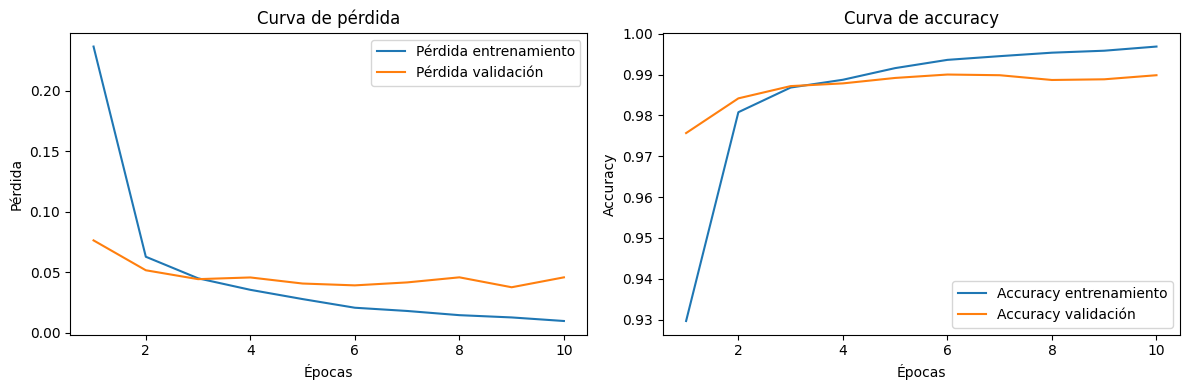

In [ ]:
# Convertir historial a un diccionario
hist = historial.history
epocas_real = range(1, len(hist['loss']) + 1)

plt.figure(figsize=(12, 4))

# Gráfico de pérdida
plt.subplot(1, 2, 1)
plt.plot(epocas_real, hist['loss'], label='Pérdida entrenamiento')
plt.plot(epocas_real, hist['val_loss'], label='Pérdida validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curva de pérdida')
plt.legend()

# Gráfico de exactitud
plt.subplot(1, 2, 2)
plt.plot(epocas_real, hist['accuracy'], label='Accuracy entrenamiento')
plt.plot(epocas_real, hist['val_accuracy'], label='Accuracy validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.title('Curva de accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## 9. Evaluación del modelo en el conjunto de prueba

Ahora que el modelo está entrenado, lo evaluamos en el conjunto de **test** (datos que el modelo nunca vio):

1. Calcular `loss` y `accuracy` en test.  
2. Predecir las clases para `x_test`.  
3. Crear una **matriz de confusión**.  
4. Generar un **reporte de clasificación** con:
   - Precision
   - Recall
   - F1-score


In [ ]:
# 9.1 Evaluación global en test
test_loss, test_acc = modelo.evaluate(x_test, y_test, verbose=0)
print(f'Pérdida en test: {test_loss:.4f}')
print(f'Accuracy en test: {test_acc:.4f}')


Pérdida en test: 0.0307
Accuracy en test: 0.9901


In [ ]:
# 9.2 Predicciones sobre el conjunto de prueba
y_pred_probs = modelo.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print('Shape de y_pred:', y_pred.shape)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Shape de y_pred: (10000,)


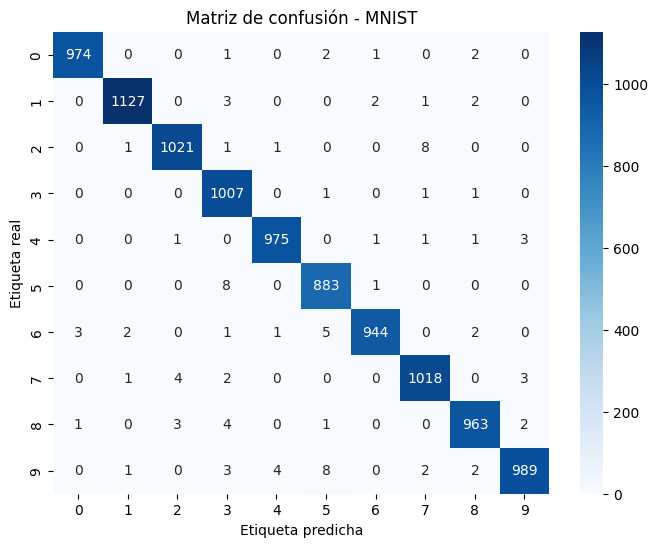

In [ ]:
# 9.3 Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Etiqueta predicha')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión - MNIST')
plt.show()


Pregunta:
Cuales son los principales patrones de errores

* Principales patrones de error
 Respuesta:El modelo tiende a equivocarse con los numeros que comparte caracteristicas geometricas como por ejemplo el 0 con el 6 o el 4 con el 9.(por ejemplo lineas rectas, o circulos)

* El 9 es el dígito más difícil para el modelo.
 Respuesta:Analizando el reporte de clasificacion, este es el que tiene menor valor en el recall en comparacion al resto.Esto podria suceder ya que puede asimilarse a la forma del 4 en algunos casos.


* Confusiones comunes, ya que la forma puede parecerse.
 Respuesta:El 4 con el 9 tiende a confundirse posiblemente por la forma cerrada que tiene en la parte superior. el 1 con el 7 tambien tiende a parecerse

* Error esperable porque ambos tienen estructuras similares.
 Respuesta: Podria ser el 3 con el 8 o el 5 con el 6 ya que si se escriben rapido puede que su forma no quede tan definida y de para interpretar error.

### Nivel de calidad del modelo


Sus observaciones en relacion a la matriz de confusión
 Respuesta:
 En general logramos apreciar de que el modelo en la mayoria de los casos coincide con las predicciones correspondientes, lo que significa que el error es muy bajo y mayormente solo en casos donde la forma de los numeros puede ser similar lo que hace que sea mas complejo para el modelo definir el numero correcto.
 Como coclusion, consideramos de que el modelo generaliza bien y que el error es muy bajo.



* La matriz muestra que el modelo clasifica correctamente la gran mayoría de las imágenes.

* Los valores más altos están en la diagonal principal, lo que indica predicciones correctas.

In [ ]:
# 9.4 Reporte de clasificación
print('Reporte de clasificación:\n')
print(classification_report(y_test, y_pred))


Reporte de clasificación:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Preguntas:



1. **¿Cuál es la forma original de `x_train` y por qué no es suficiente para una CNN?**<br>
**R=** La forma original es `(60000, 28, 28)`. No es suficiente porque las CNNs esperan una dimensión de canal explícita para las imágenes, incluso en escala de grises.
2. **¿Qué significa cada dimensión de `(60000, 28, 28, 1)`?**<br>
**R=** `60000` es el número de imágenes, el primer `28` es el alto de la imagen, el segundo `28` es el ancho de la imagen, y `1` es el número de canales (para imágenes en escala de grises).
3. **¿Por qué normalizamos los píxeles entre 0 y 1?**<br>
**R=** Para estabilizar el entrenamiento (gradientes más manejables), evitar que ciertas características dominen por su escala, y mejorar la generalización del modelo.
4. **¿Qué ocurre si se elimina la normalización?**<br>
**R=** La ausencia de normalización hace que el entrenamiento sea más complicado, lento y menos efectivo, pudiendo llevar a un modelo con peor rendimiento y generalización.
5. **¿Qué función cumple `Conv2D` dentro del modelo?**<br>
**R=** `Conv2D` aplica filtros convolucionales para extraer automáticamente características jerárquicas (como bordes, texturas) de las imágenes.
6. **¿Qué función cumple `MaxPooling2D`?**<br>
**R=** `MaxPooling2D` reduce la dimensionalidad espacial de los mapas de características, lo que ayuda a hacer el modelo más robusto a pequeñas variaciones de posición y reduce la cantidad de parámetros y cálculos.
7. **¿Por qué se usa `Flatten()` antes de las capas densas?**<br>
**R=** `Flatten()` transforma los mapas de características 2D (o 3D) resultantes de las capas convolucionales en un vector 1D, lo cual es necesario para que las capas densas (Fully Connected) puedan procesarlos.
8. **¿Por qué la última capa tiene 10 neuronas?**<br>
**R=** Es proporcional al numero de resultados que podemos tener, en nuestro caso, los números de 0 a 9.
9. **¿Por qué se usa `softmax` en la salida?**<br>
**R=** Softmax convierte un vector de números reales en un vector probabilidades. Cada valor representa la probabilidad de que la entrada pertenezca a una clase especifica.
10. **¿Por qué se usa `sparse_categorical_crossentropy`?**<br>
**R=** Se utiliza para calcular la función de perdida en problemas de clasificación.
11. **¿Qué ocurre si aumenta demasiado el learning rate?**<br>
**R=** Si el *learning rate* es muy alto, el modelo se vuelve inestable, los pesos pueden oscilar o divergir, y el entrenamiento no converge, saltándose el mínimo óptimo.
12. **¿Qué ocurre si el learning rate es demasiado pequeño?**<br>
**R=** Si el *learning rate* es muy bajo, el modelo aprende muy lentamente, el entrenamiento es excesivamente largo y puede quedarse atrapado en mínimos locales subóptimos.
13. **¿Cómo afecta el batch size al entrenamiento?**<br>
**R=** Batches pequeños generan actualizaciones más ruidosas pero pueden llevar a una mejor generalización. Batches grandes proporcionan gradientes más estables, pero pueden consumir más memoria y aumentar el riesgo de sobreajuste.
14. **¿Qué diferencia hay entre `loss` y `val_loss`?**<br>
**R=** "loss" Es la metrica de perdida con los datos de entrenamiento, mientras que "val_loss" es la metrica de perdida con los datos de test.
15. **¿Cómo se detecta overfitting en las curvas de aprendizaje?**<br>
**R=** Si la curva de "accuracy" sigue aumentando mientras que "val_accuracy" disminuye. O, si la curva de "loss" disminuye mientras que la curva de "val_loss" aumenta.
16. **¿Qué hace `EarlyStopping`?**<br>
**R=** EarlyStopping es una especie de "freno" que le dice al modelo que deje de entrenar cuando las metricas dejan de progresar.
17. **¿Qué hace `ModelCheckpoint`?**<br>
**R=** Guarda el modelo con el mejor rendimiento alcanzado durante el entrenamiento (según una métrica monitoreada), previniendo el sobreajuste y facilitando la recuperación del mejor modelo.
18. **¿Por qué se evalúa finalmente con datos de test?**<br>
**R=** Para poder probar con datos sin etiqueta en su variable objetivo, esto para verificar la fiabilidad del modelo.
19. **¿Qué representa la diagonal principal de la matriz de confusión?**<br>
**R=** Representa los acierto que tuvo el modelo.
20. **¿Qué clases se confunden más y por qué?**<br>
**R=** Según la matriz de confusión, las confusiones son mínimas, pero los números con formas visualmente similares (como el 4 y el 9, o 3 y 8) son los más propensos a ser confundidos debido a la superposición de características visuales en dígitos escritos a mano.
21. **¿Qué significa precision?**<br>
**R=** La precisión mide la proporción de predicciones positivas correctas. Es decir, de todas las veces que el modelo dijo que algo era positivo.
22. **¿Qué significa recall?**<br>
**R=** El recall (sensibilidad) mide la proporción de verdaderos positivos que fueron identificados correctamente. Es decir, todos los elementos que *realmente eran* positivos.
23. **¿Qué significa F1-score?**<br>
**R=** El F1-score es la media de la precisión y el recall. Es una métrica que busca un equilibrio entre ambas, siendo útil cuando hay un desbalance de clases o cuando se necesita un buen desempeño tanto en identificar positivos como en no equivocarse al hacerlo.
24. **¿El modelo generaliza bien? Justifica con métricas.**<br>
**R=** Sí, el modelo generaliza muy bien. Su `accuracy` en el conjunto de test es del 99.01% y la `loss` es de 0.0307, valores muy cercanos a los de validación y entrenamiento, lo que indica que el modelo no ha sobreajustado y tiene un rendimiento consistente en datos no vistos.
25. **¿Qué mejora concreta aplicarías al modelo y por qué?**<br>
**R=** Dada la alta precisión, una mejora sería implementar Data Augmentation (aumento de datos). Esto generaría nuevas variaciones de las imágenes de entrenamiento (rotaciones, traslaciones, zoom) haciendo el modelo más robusto y menos propenso a pequeñas variaciones en los dígitos escritos a mano.